# UAV Perching Data Visualization

This notebook iterates over all ROS bag files in `../bags/uav_perching/`, extracts optoforce wrench topics, and generates time-series plots using the **scienceplots** style.



In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'ieee'])
from bagpy import bagreader

# output directory for figures (relative to notebook)
fig_dir = os.path.join(os.getcwd(), "figures_uav_perching")
os.makedirs(fig_dir, exist_ok=True)
print(f"Figures will be written to: {fig_dir}")

Figures will be written to: /home/jakob/SOBER_A_Soft_Base_Passive_Gripper_for_Surface_Attachment/visualization/figures_uav_perching


In [ ]:
# iterate over bag files in uav_perching directory and plot wrench data
bag_dir = os.path.join(os.getcwd(), "..", "bags", "uav_perching")

def process_bag(bag_path: str):
    print(f"\n=== processing {os.path.basename(bag_path)} ===")
    b = bagreader(bag_path)
    topics = b.topic_table["Topics"].tolist()
    for topic in topics:
        # only look at optoforce wrench topics (raw/filtered)
        if "OptoForceWrench" not in topic:
            continue
        print(f"  topic: {topic}")
        csvfile = b.message_by_topic(topic)
        try:
            df = pd.read_csv(csvfile)
        except Exception as e:
            print("    failed to read csv", e)
            continue
        if df.empty:
            continue
        t0 = df["Time"].iloc[0]
        df["time_s"] = df["Time"] - t0

        fig, ax = plt.subplots(figsize=(5, 3), constrained_layout=True)
        for col in df.columns:
            if col in ["Time", "time_s"]:
                continue
            ax.plot(df["time_s"], df[col], label=col)
        ax.set_title(f"{os.path.basename(bag_path)} | {os.path.basename(topic)}")
        ax.set_xlabel("time [s]")
        ax.grid(True, alpha=0.4)
        ax.legend(fontsize=6, loc="upper right")

        out = os.path.join(fig_dir, f"{os.path.basename(bag_path)}_{os.path.basename(topic).replace('/','_')}.pdf")
        fig.savefig(out, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"    saved {out}")

# loop through directory
for fname in sorted(os.listdir(bag_dir)):
    if not fname.endswith(".bag"):
        continue
    process_bag(os.path.join(bag_dir, fname))


=== processing 2026-03-06-11-49-55.bag ===
[INFO]  Data folder /home/jakob/SOBER_A_Soft_Base_Passive_Gripper_for_Surface_Attachment/visualization/../bags/uav_perching/2026-03-06-11-49-55 already exists. Not creating.
  topic: /optoforce_node/OptoForceWrench


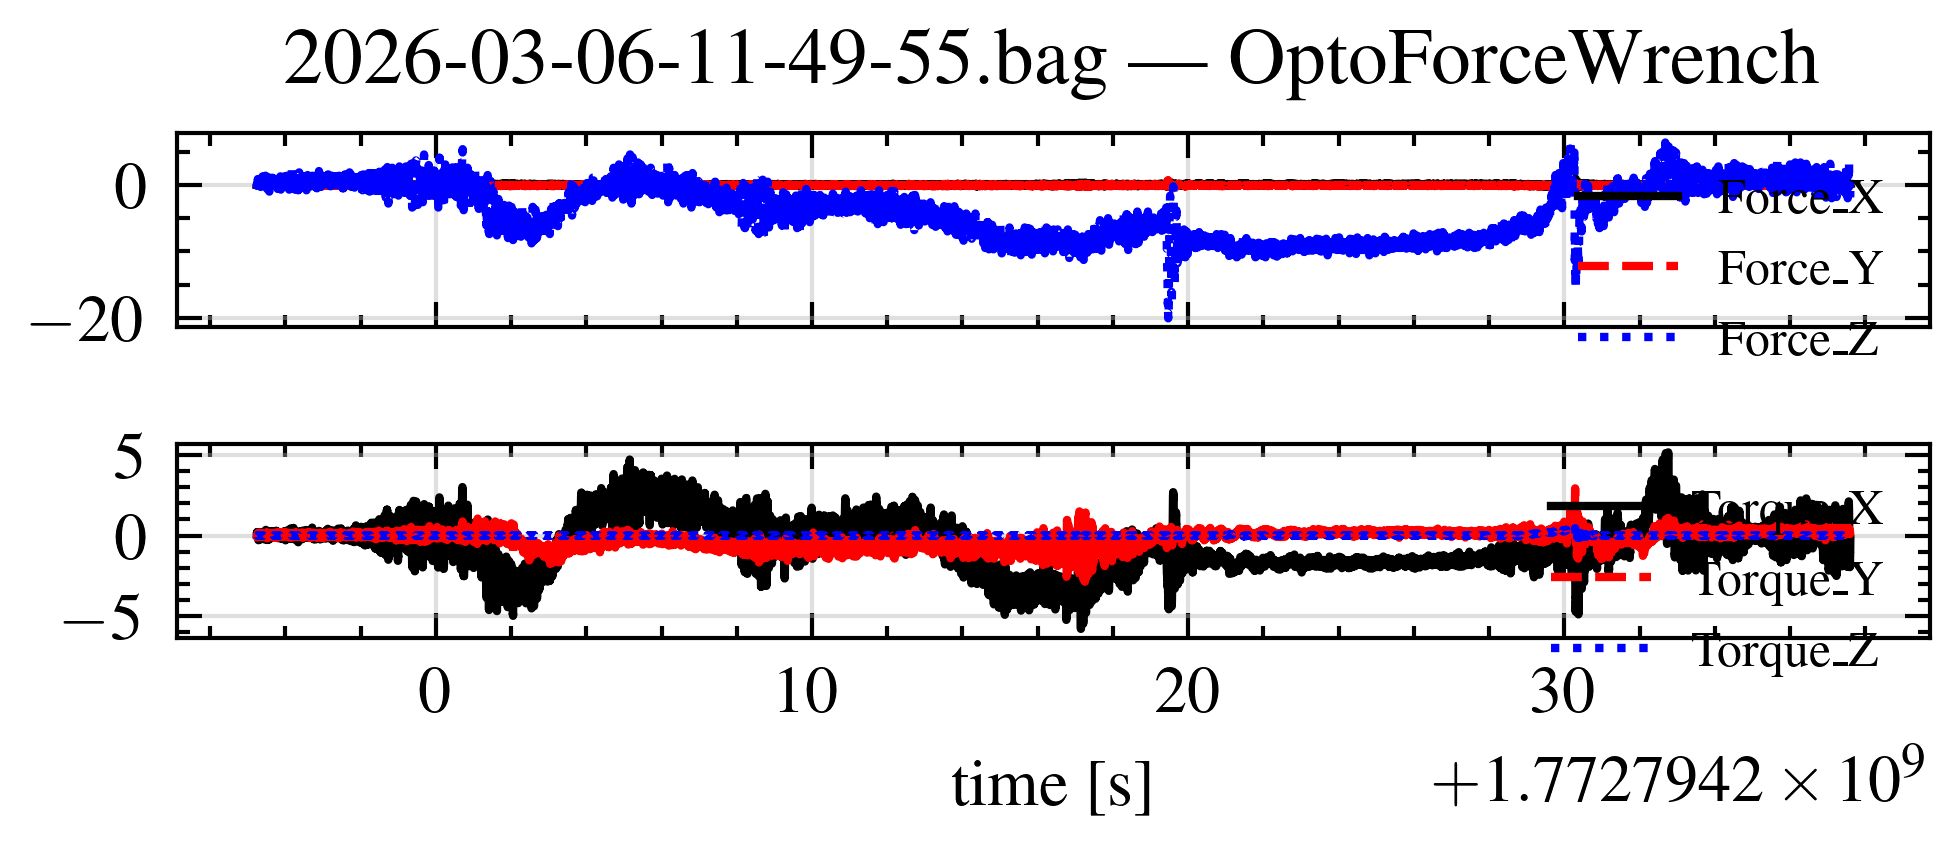

    saved /home/jakob/SOBER_A_Soft_Base_Passive_Gripper_for_Surface_Attachment/visualization/figures_uav_perching/2026-03-06-11-49-55.bag_OptoForceWrench.pdf
  topic: /optoforce_node/OptoForceWrench_filtered2


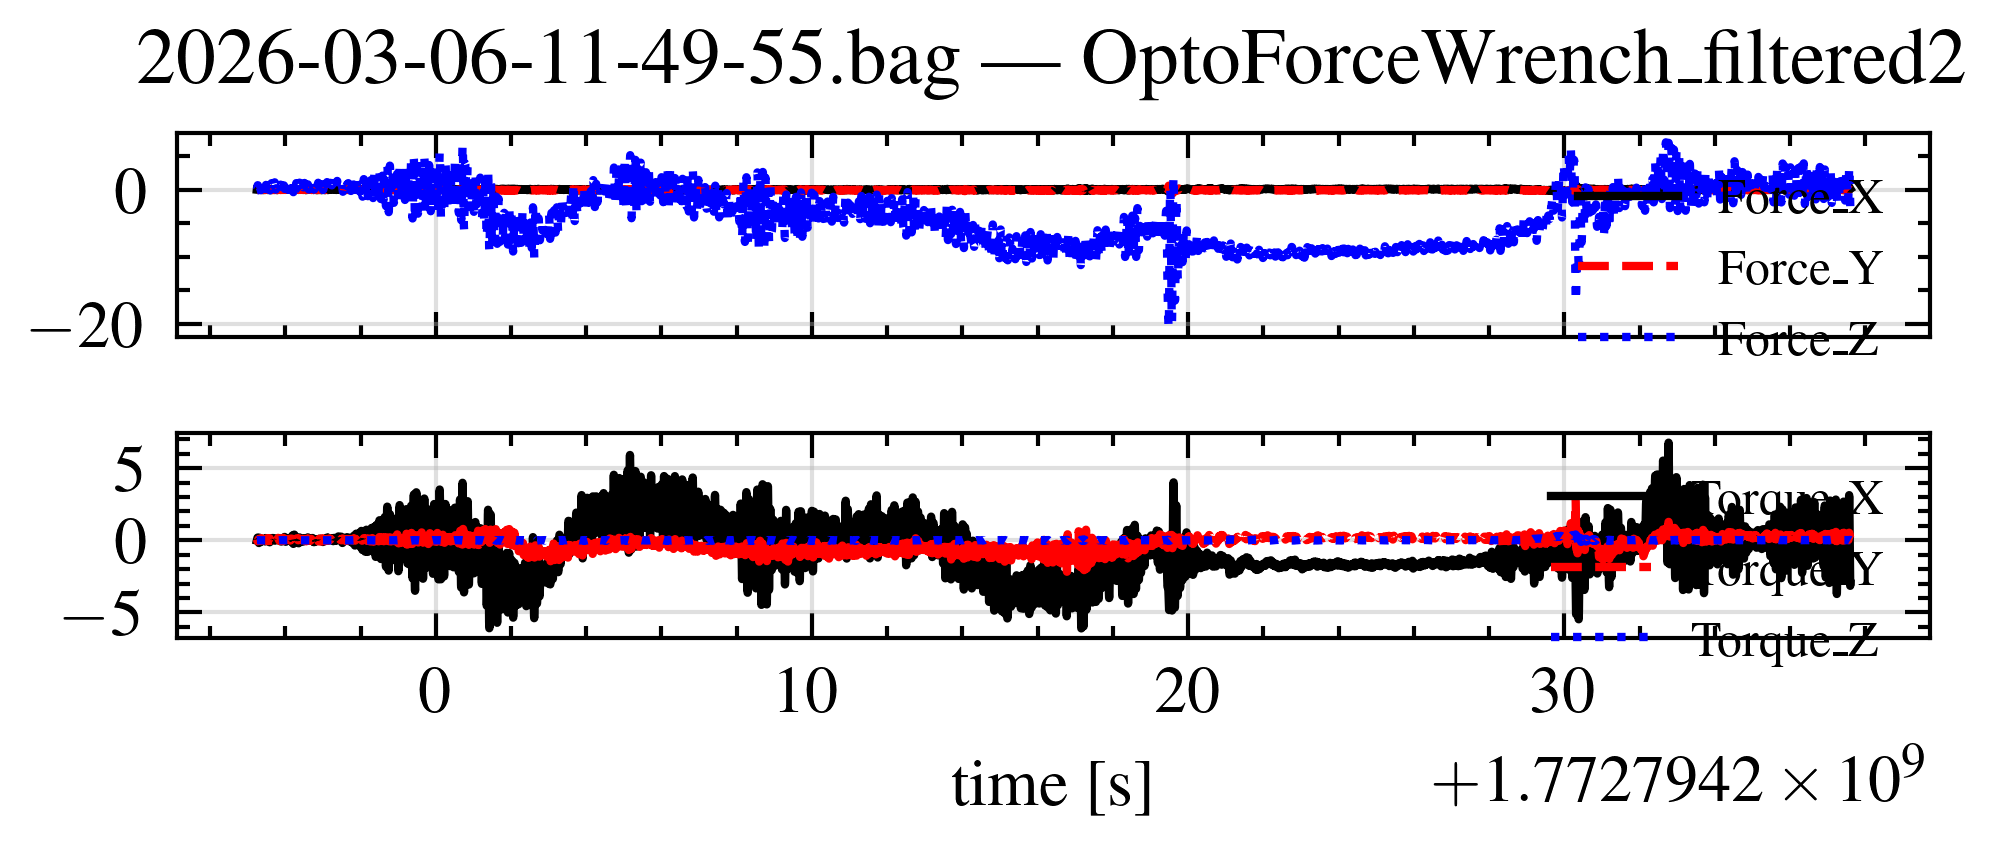

    saved /home/jakob/SOBER_A_Soft_Base_Passive_Gripper_for_Surface_Attachment/visualization/figures_uav_perching/2026-03-06-11-49-55.bag_OptoForceWrench_filtered2.pdf
  topic: /optoforce_node/OptoForceWrench_raw


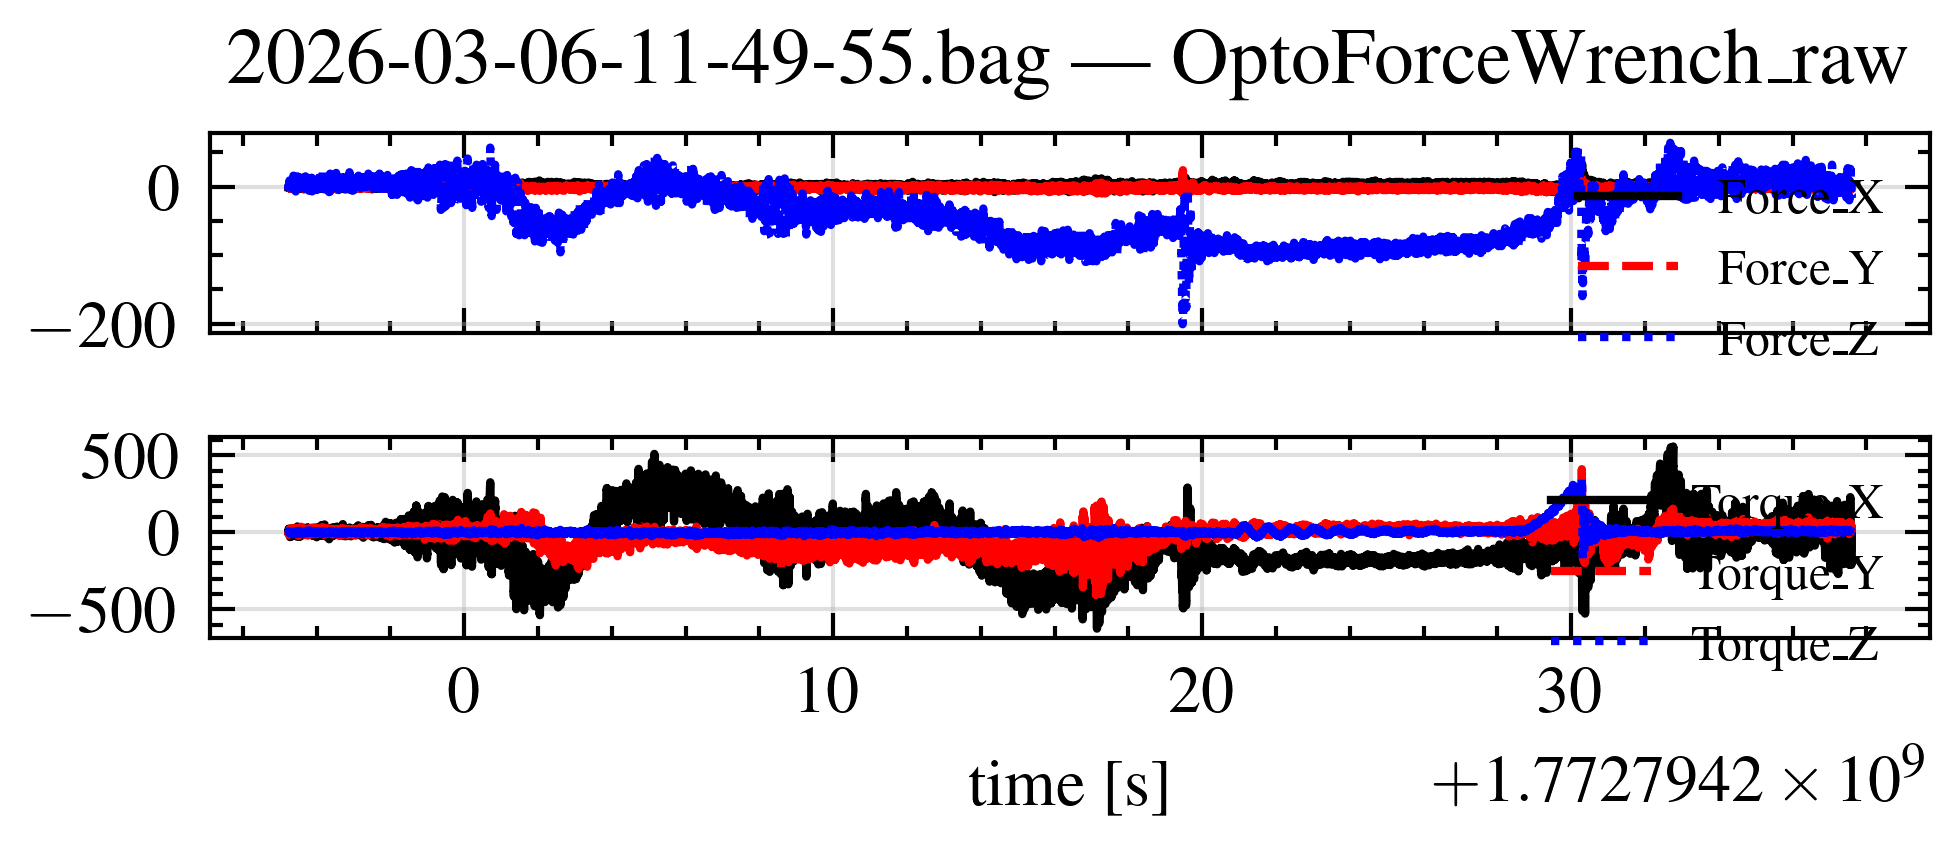

    saved /home/jakob/SOBER_A_Soft_Base_Passive_Gripper_for_Surface_Attachment/visualization/figures_uav_perching/2026-03-06-11-49-55.bag_OptoForceWrench_raw.pdf
  topic: /rosout


KeyError: 'wrench.force.x'

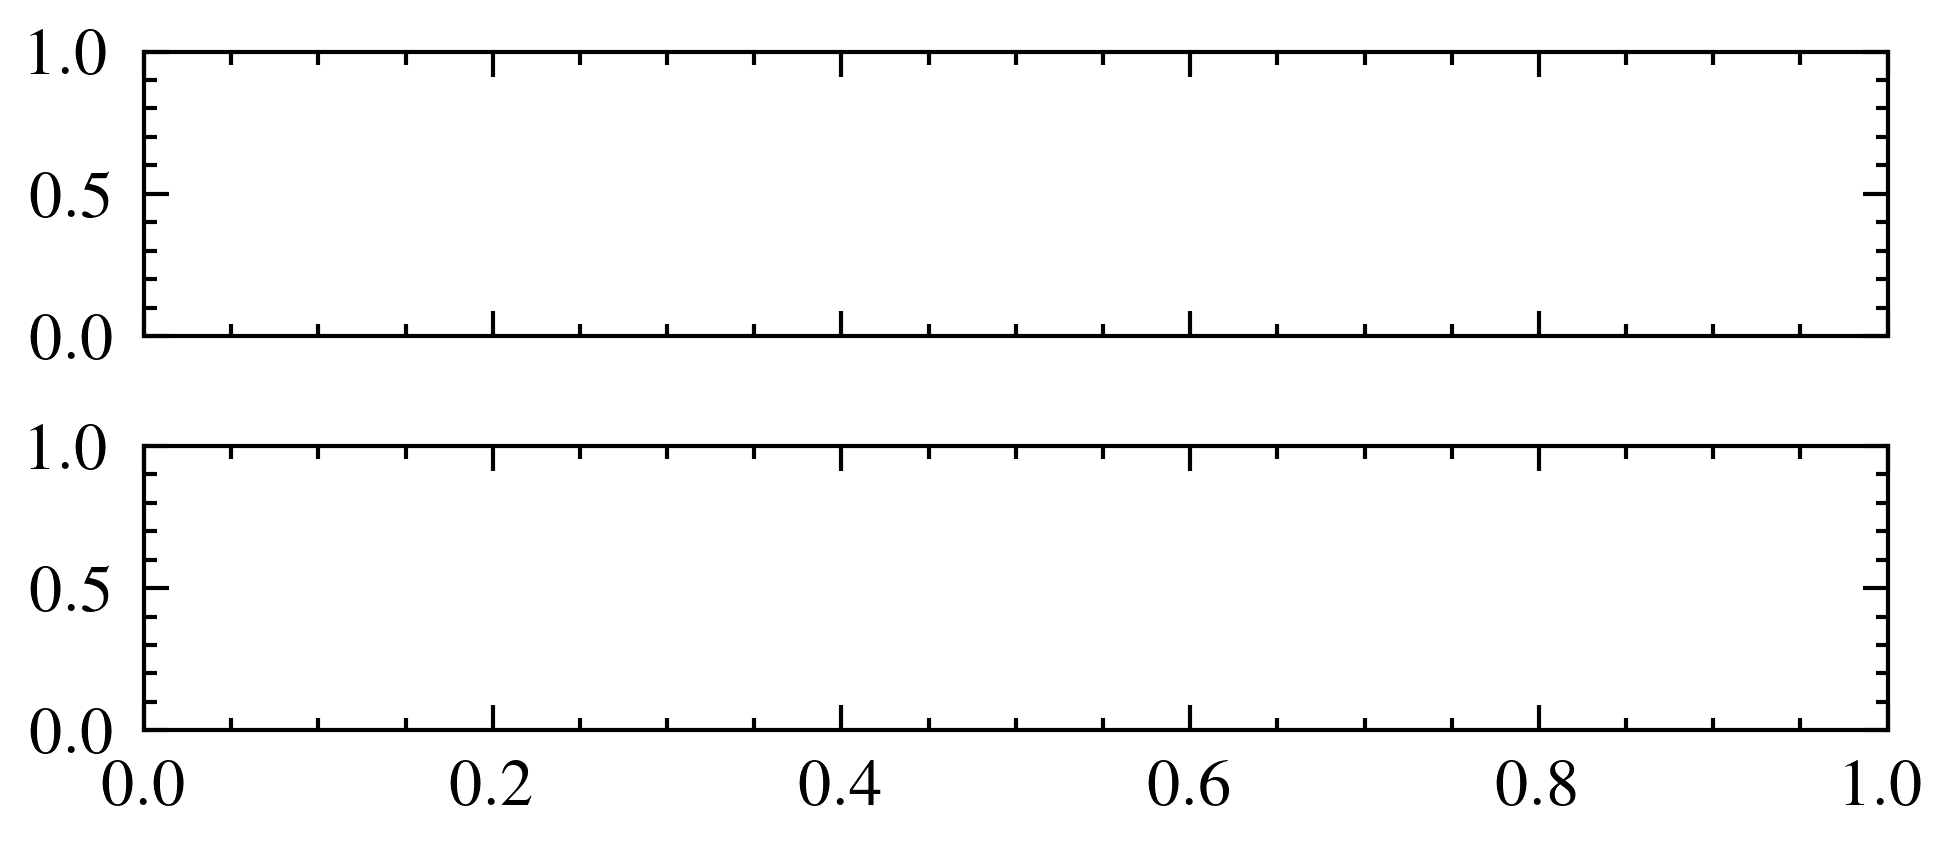

In [18]:
# iterate over bag files in uav_perching directory and plot wrench data
bag_dir = os.path.join(os.getcwd(), "..", "bags", "uav_perching")
# IEEE column-sized figures
FIGSIZE_IN = (3.25, 1.4)
DPI = 600
def process_bag(bag_path: str):
    print(f"\n=== processing {os.path.basename(bag_path)} ===")
    b = bagreader(bag_path)
    topics = b.topic_table["Topics"].tolist()
    for topic in topics:
        # only look at optoforce wrench topics (raw/filtered)
        print(f"  topic: {topic}")
        csvfile = b.message_by_topic(topic)
        try:
            df = pd.read_csv(csvfile)
        except Exception as e:
            print("    failed to read csv", e)
            continue
        if df.empty:
            continue
        t0 = df["Time"].iloc[0]
        df["time_s"] = df["Time"] - t0

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=FIGSIZE_IN, constrained_layout=True, sharex=True)
        
        ax1.plot(df['Time'], df['wrench.force.x'], label='Force_X')
        ax1.plot(df['Time'], df['wrench.force.y'], label='Force_Y')
        ax1.plot(df['Time'], df['wrench.force.z'], label='Force_Z')
        
        ax1.set_title(f"{os.path.basename(bag_path)} | {os.path.basename(topic)}")
        ax2.plot(df['Time'], df['wrench.torque.x'], label='Torque_X')
        ax2.plot(df['Time'], df['wrench.torque.y'], label='Torque_Y')
        ax2.plot(df['Time'], df['wrench.torque.z'], label='Torque_Z')
        ax2.set_xlabel("time [s]")
        ax1.grid(True, alpha=0.4)
        ax2.grid(True, alpha=0.4)
        ax1.legend(fontsize=6, loc="upper right")
        ax2.legend(fontsize=6, loc="upper right")
        out = os.path.join(fig_dir, f"{os.path.basename(bag_path)}_{os.path.basename(topic).replace('/','_')}.pdf")
        fig.savefig(out, dpi=DPI, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"    saved {out}")
        
# loop through directory
for fname in sorted(os.listdir(bag_dir)):
    if not fname.endswith(".bag"):
        continue
    process_bag(os.path.join(bag_dir, fname))
